# Granite 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from granite.features import Features
from granite.fd_trees import FDTree
from granite.decompositions import get_components_brute_force, get_regional_decompositions
from granite.plots import partial_dependence_plot, plot_legend

## Setup
We must set a `Features` object to let the code know which features are numerical, categorical, integers etc. This will
help computing functional decompositions more efficiently (e.g. cat features have finite cardinality), and will also help
determine splits when fitting a decision tree.

In [6]:
def generate_problem(N, seed):
    # Generate input
    np.random.seed(seed)
    X_1 = np.random.normal(0, 1, size=(N,))
    X_2 = 2 * np.random.randint(0, 2, size=(N,)) - 1
    X_3 = 2 * np.random.randint(0, 2, size=(N,)) - 1
    X_4 = X_3 + 0.5 * np.random.normal(0, 1, size=(N,))

    # Model to explain
    def f(X):
        return 3 * X[:, 0] * X[:, 1] + X[:, 2] + 2 * X[:, 3]
    return np.column_stack((X_1, X_2, X_3, X_4)), h

# We generate the data and models. The data X is stored in a (N, d) numpy array
X, f = generate_problem(2000, 42)
features = Features(
                X, 
                names=[f"x{i}" for i in range(1, 5)], 
                types=["num", ["ordinal", "-1", "1"], ["ordinal", "-1", "1"], "num"]
            )
features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | x1                 | num                | inf        | [0]              |
| 1 | x2                 | ordinal            | 2          | [1]              |
| 2 | x3                 | ordinal            | 2          | [2]              |
| 3 | x4                 | num                | inf        | [3]              |
-------------------------------------------------------------------------------



The `get_components_brute_force` takes as input a model `f`, evaluation points `X` at which the functional decomposition is evaluated, reference points `X` used for masking
(does not need to be the whole dataset), a `Features` object, and a flag `anchored` to let it know whether to return the anchored decomposition or the marginal one.
We will be computing the anchored decomposition in storing it in matrices $H^{k}$ such that

$$ H^{k}_{ij} = f(x^{(i)}_k, x^{(j)}_{-k}) - f(x^{(j)})$$

These matrices are more efficient to compute than their Mobieus inverse

$$ R^{k}_{ij} = f(x^{(i)}_k, x^{(j)}_{-k})$$

since they are sparser (their components which are know to be zero will not need to be computed).

In [7]:
# Compute the Anchored Decomposition. Averaging it column-wise leads to the marginal decomposition.
decomposition = get_components_brute_force(f, X, X, features, anchored=True)
print(decomposition.keys())
print(decomposition[()].shape) # The null set is the model evaluation h(x^(i)) at all datapoints
print(decomposition[(0,)].shape)  # The component (0,) is a NxN matric whose ij term is h_{0,x^(j)}(x^(i))

dict_keys([(), (0,), (1,), (2,), (3,)])
(2000,)
(2000, 2000)


## Pure-vs-Full Marginal effect for $X_1$
Thin lines are ICE curves and the thick line is the PDP

$$ f^{PDP}(x_k) = \mathbb{E}_{z\sim D}[f(x_k, z_{-k})].$$

Both of these effects are marginal (not conditional) since we replace feature $X_1$ with other values
from the dataset, irrespective of possible correlations. Disagreements among these curves are therefore indicative of strong **feature interactions** involving feature $X_1$.

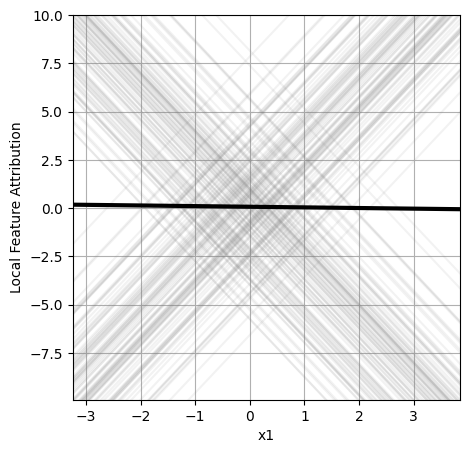

In [9]:
partial_dependence_plot(decomposition, X, features, idxs=[0], figsize=(5, 5))

We reduce disagreements by fitting a decision tree that minimizes the difference between the pure and full marginal effects of $X_1$. Given the
$N\times N$ matrices $H^k$, it is possible to effciently compute the pure-full disagreements by comparing row-wise to column-wise averages.

In [10]:

class Minimize_Superset(FDTree):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def fit(self, X, decomposition, u):
        """
        Fit the FDTree

        Parameters
        ----------
        X : (N, n_features) np.ndarray
            The data on which to fit the tree. The ith column of `X` must be the ith feature
            in the Features object passed to the constructor.
        decomposition : dict{Tuple: np.ndarray}
            The functional decomposition used to compute the objective.
            It needs to be anchored with foreground=background i.e.
            `decomposition[(0,)].shape = (N, N)`.
        u : Tuple(int)
            The subset whose pure-full disagreement is minimized
        """

        self.X = X
        self.N, self.D = X.shape
        self.u = u
        assert np.shape(decomposition[u]) == (self.N, self.N), "An Anchored decomposition with foreground=background is needed"
        self.H = decomposition[u]
        self.loa_factor = 1 / decomposition[()].var() # To have an loa 0-100%
        self.n_regions = 0
        # Loss function is the difference between full and partial effects
        loa = np.mean((self.H.mean(0) - (-1)**len(u)*self.H.mean(1))**2)
        # Start recursive tree growth
        self.root, self.final_objective, self.n_regions = self._tree_builder(np.arange(self.N), depth=0, loa=loa)
        self.final_loa = self.final_objective - self.alpha * self.n_regions
        return self


    def _get_objective_for_splits(self, instances_idx, feature):
        """
        Given the indices of the datapoints in the current leaf, compute
        the loss function for a variety of split candidates.
        """
        x_i = self.X[instances_idx, feature]

        splits = self._get_split_candidates(x_i, feature)

        # No split possible
        if len(splits) == 0:
            return [], [], []

        # Otherwise we optimize the objective
        loa_left = np.zeros(len(splits))
        loa_right = np.zeros(len(splits))
        to_keep = np.zeros((len(splits))).astype(bool)

        # Iterate over all splits
        for i, split in enumerate(splits):
            left = instances_idx[x_i <= split][:, np.newaxis]
            right = instances_idx[x_i > split][:, np.newaxis]
            H_left = self.H[left, left.T]
            H_right = self.H[right, right.T]
            to_keep[i] = min(len(left), len(right)) >= self.min_samples_leaf
            loa_left[i]  = np.sum((H_left.mean(0) - (-1)**len(self.u)*H_left.mean(1))**2)
            loa_right[i]  = np.sum((H_right.mean(0) - (-1)**len(self.u)*H_right.mean(1))**2)

        return splits[to_keep], loa_left[to_keep], loa_right[to_keep]

In [11]:
# We want to split on the remaining features so we call the .select method
# `branching_per_node>1` finds better solutions than greedy since multiple splits can be attempted as a given node
tree = Minimize_Superset(features.select([1, 2, 3]), max_depth=2, save_losses=True, branching_per_node=3)
tree.fit(X[:, [1, 2, 3]], decomposition, (0,))
tree.print(verbose=False)

If x2 ≤ -1.0000:
|   Region 0
else:
|   Region 1
Final LoA 0.0000


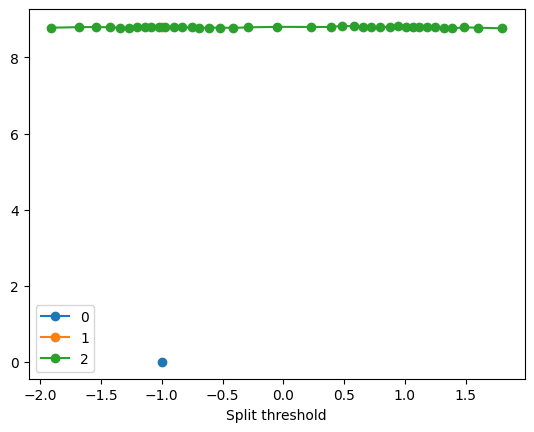

In [12]:
# Plot the loss function as a function of split candidate
plt.figure()
for i in range(3):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i)
plt.xlabel("Split threshold")
plt.legend()

In [13]:
# Use the tree to compute regional decompositions
regions = tree.predict(X[:, [1, 2, 3]])
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
# TODO this does not yield the intended result, my code that generates rules does not
# work properly for feature X_2\in {-1, 1}
print(rules)
regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
regional_backgrounds = [[]] * n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = X[regions == r]


[1 0 1 0 0 1 0 1 1 0]
{0: 'x2 ∈ []', 1: 'x2 ∈ [-1,1]'}


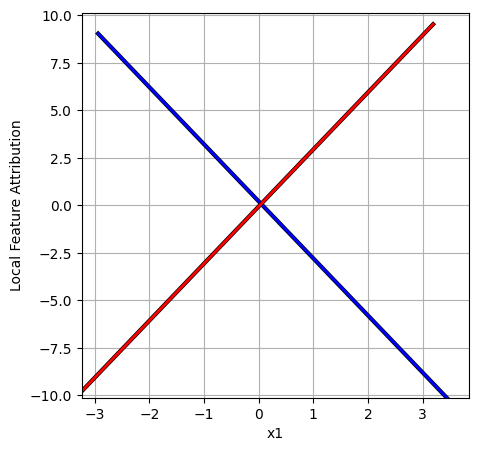

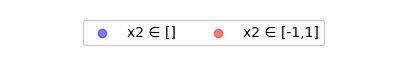

In [14]:
partial_dependence_plot(regional_decompositions, regional_backgrounds, features, idxs=[0], figsize=(5, 5), centered=True)
plot_legend(rules, ncol=2)

Here the regional ICE (thin lines) and PDP (thick lines) are perfectly superposed.

## Marginal-vs-Conditional Effect for $X_4$

The Conditional Effects are easier to compute using the matrix $R^k_{ij} = f_S(x^{(i)}_S, x^{(j)}_{-S})$ instead of the $H_k$ matrices.
They also rely on bins : masking will only be done using datapoints that land in the same bin as the evaluation point.

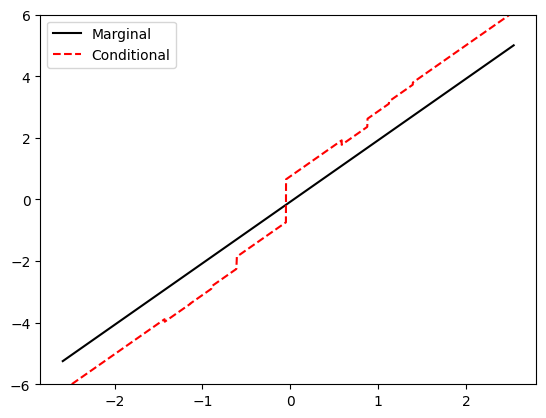

In [15]:

n_bins=10
quantiles = np.percentile(X[:, 3], q=[i*100 / n_bins for i in range(n_bins+1)], axis=0)
binned_feature = np.clip(np.digitize(X[:, 3], bins=quantiles) - 1, a_min=0, a_max=n_bins-1)
R = decomposition[(3,)] + decomposition[()]

def get_marginal_conditional_effects(binned_feature, R):
    marginal_effect = R.mean(1)
    conditional_effect = np.zeros((binned_feature.shape[0],))
    for b in np.unique(binned_feature):
        inside_bin = np.where(binned_feature == b)[0][:, np.newaxis]
        conditional_effect[inside_bin.ravel()] = R[inside_bin, inside_bin.T].mean(1)
    return marginal_effect, conditional_effect

marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_feature, R)
argsort_x_i = np.argsort(X[:, 3])
plt.plot(X[argsort_x_i, 3], marginal_effect[argsort_x_i], 'k-', label="Marginal")
plt.plot(X[argsort_x_i, 3], conditional_effect[argsort_x_i], 'r--', label="Conditional")
plt.ylim(-6, 6)
plt.legend()

In [20]:
class PDP_vs_MPlot(FDTree):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def fit(self, X, decomposition, i, binned_feature):
        """
        Fit the FDTree

        Parameters
        ----------
        X : (N, n_features) np.ndarray
            The data on which to fit the tree. The ith column of `X` must be the ith feature
            in the Features object passed to the constructor.
        decomposition : dict{Tuple: np.ndarray}
            The functional decomposition used to compute the objective.
            It needs to be anchored with foreground=background i.e.
            `decomposition[(0,)].shape = (N, N)`.
        i : int
            The index of the feature whose marginal and conditional effects are computed.
        binned_feature : np.ndarray[int]
            Binned values for feature i, used to compute conditional expectations
        """

        self.X = X
        self.N, self.D = X.shape
        assert np.shape(decomposition[(i,)]) == (self.N, self.N), "An Anchored decomposition with foreground=background is needed"
        self.R = decomposition[(i,)] + decomposition[()]
        self.loa_factor = 1 / self.R.var()
        self.binned_data = binned_feature
        self.n_regions = 0
        marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_feature, self.R)
        # The loss is the difference between the marginal and conditional effects
        loa = np.mean((marginal_effect - conditional_effect)**2)
        # Start recursive tree growth
        self.root, self.final_objective, self.n_regions = self._tree_builder(np.arange(self.N), depth=0, loa=loa)
        self.final_loa = self.final_objective - self.alpha * self.n_regions
        return self


    def _get_objective_for_splits(self, instances_idx, feature):
        x_i = self.X[instances_idx, feature]

        splits = self._get_split_candidates(x_i, feature)

        # No split possible
        if len(splits) == 0:
            return [], [], []

        # Otherwise we optimize the objective
        loa_left = np.zeros(len(splits))
        loa_right = np.zeros(len(splits))
        to_keep = np.zeros((len(splits))).astype(bool)

        # Iterate over all splits
        for i, split in enumerate(splits):
            left = instances_idx[x_i <= split][:, np.newaxis]
            right = instances_idx[x_i > split][:, np.newaxis]
            R_left = self.R[left, left.T]
            R_right = self.R[right, right.T]
            to_keep[i] = min(len(left), len(right)) >= self.min_samples_leaf
            marginal_left, conditional_left = get_marginal_conditional_effects(self.binned_data[left.ravel()], R_left)
            marginal_right, conditional_right = get_marginal_conditional_effects(self.binned_data[right.ravel()], R_right)
            loa_left[i]  = np.sum((marginal_left - conditional_left)**2)
            loa_right[i]  = np.sum((marginal_right - conditional_right)**2)

        return splits[to_keep], loa_left[to_keep], loa_right[to_keep]

In [21]:
# We only split along the features that exclude X_4
tree = PDP_vs_MPlot(features.select([0, 1, 2]), max_depth=2, save_losses=True, branching_per_node=2, alpha=0.01)
tree.fit(X[:, [0, 1, 2]], decomposition, 3, binned_feature=binned_feature)
tree.print(verbose=True)

LoA 0.0579
Samples 2000
If x3 ≤ -1.0000:
|   LoA 0.0009
|   Samples 1000
|   Region 0
else:
|   LoA 0.0008
|   Samples 1000
|   Region 1
Final LoA 0.0016


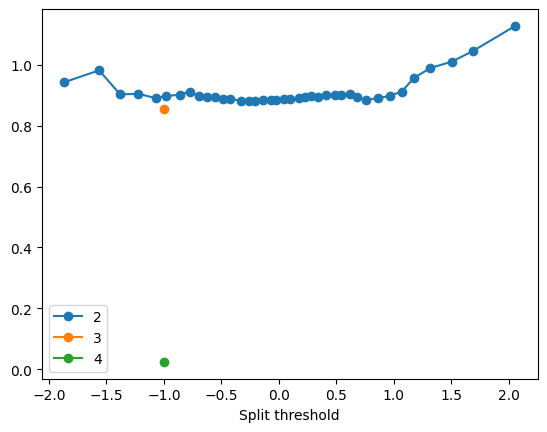

In [22]:
plt.figure()
for i in range(3):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i+2)
plt.xlabel("Split threshold")
plt.legend()

In [23]:
regions = tree.predict(X[:, [0, 1, 2]])
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
# TODO again there is a bug in the rule
print(rules)
regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
regional_backgrounds = [[]] * n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = X[regions == r]

[0 0 1 1 1 1 0 1 1 1]
{0: 'x3 ∈ []', 1: 'x3 ∈ [-1,1]'}


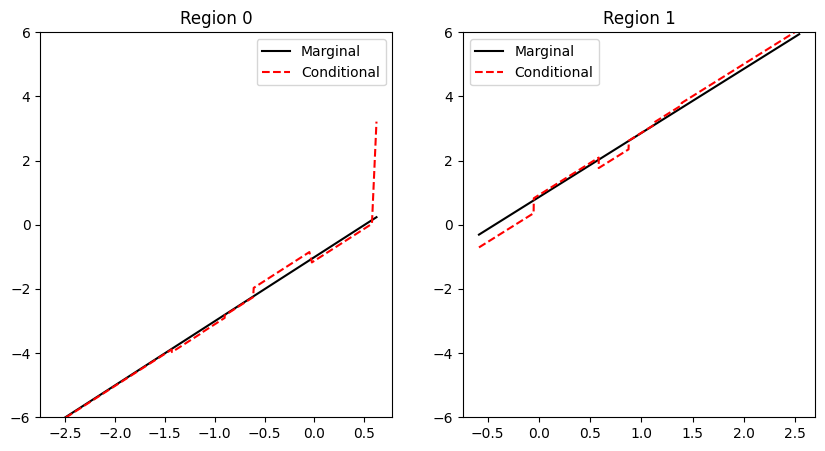

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for r in range(tree.n_regions):
    R = regional_decompositions[r][(3,)] + regional_decompositions[r][()]
    X_region = regional_backgrounds[r]
    marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_feature[regions==r], R)
    argsort_x_i = np.argsort(X_region[:, 3])
    axes[r].plot(X_region[argsort_x_i, 3], marginal_effect[argsort_x_i], 'k-', label="Marginal")
    axes[r].plot(X_region[argsort_x_i, 3], conditional_effect[argsort_x_i], 'r--', label="Conditional")
    axes[r].set_ylim(-6, 6)
    axes[r].set_title(f"Region {r}")
    axes[r].legend()